# 🎤 ASR Shootout — Indian Conversational Speech Benchmark

### Vahan AI Intern Assessment | Kaggle End-to-End Evaluation Pipeline

---

> **Mission:** Find the best ASR system for Vahan’s hiring platform — where candidates
> speak Hinglish over phone calls from noisy environments and the platform must extract
> where they live.

| #   | Model                       | Type            | Key Rationale                                     |
| --- | --------------------------- | --------------- | ------------------------------------------------- |
| 1   | **Deepgram Nova-2**         | Cloud API       | Required baseline — industry standard             |
| 2   | **Sarvam AI Saaras v3**     | Cloud API       | India-specific, telephony-optimised, 22 languages |
| 3   | **Whisper large-v3**        | Open-source GPU | OpenAI multilingual open-source reference         |
| 4   | **Whisper Hindi Fine-tune** | Open-source GPU | Whisper fine-tuned on Indian speech data          |

**Primary metric → Entity Accuracy** — did the model capture the Bangalore locality name?
**Secondary → WER, CER, Latency, Cost/hr**

**Dataset:** 116 files — 20 self-recorded Hinglish + 96 GramVaani telephony Hindi

---

_Kaggle Paths:_

```
Dataset root : /kaggle/input/vahan-folder/vahan/
Self audio   : /kaggle/input/vahan-folder/vahan/Audio-files/*.mp3
GramVaani    : /kaggle/input/vahan-folder/vahan/Audio-files/gramvaani_audio/*.mp3
Ground truth : /kaggle/input/vahan-folder/vahan/final_116_clean.csv
```


## ⚙️ Section 0 — Environment Setup


In [ ]:
# Install required packages
# Kaggle pre-installs: pandas, numpy, matplotlib, seaborn, torch, transformers
# We install: deepgram-sdk, openai-whisper, jiwer, indic-transliteration, tabulate

import subprocess, sys

def pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", pkg,
                   "-q", "--disable-pip-version-check"], check=False)

packages = [
    "deepgram-sdk==3.7.7",
    "openai-whisper==20240930",
    "jiwer==3.0.3",
    "indic-transliteration",
    "tabulate",
    "pydub",
]

for pkg in packages:
    pip_install(pkg)

print("✅ All packages installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.0/165.0 kB 11.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ypy-websocket 0.8.4 requires aiofiles<23,>=22.1.0, but you have aiofiles 25.1.0 which is incompatible.
dataproc-spark-connect 1.0.2 requires websockets>=14.0, but you have websockets 13.1 which is incompatible.
google-adk 1.25.1 requires websockets<16.0.0,>=15.0.1, but you have websockets 13.1 which is incompatible.
gradio 5.50.0 requires aiofiles<25.0,>=22.0, but you have aiofiles 25.1.0 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.5/800.5 kB 18.5 MB/s eta 0:00:00


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


✅ All packages installed


In [ ]:
import os, re, time, json, wave, warnings, contextlib, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
import jiwer
from pathlib import Path
from tqdm.auto import tqdm
from tabulate import tabulate
from collections import defaultdict

warnings.filterwarnings("ignore")

# ── Kaggle Dataset Paths ──────────────────────────────────────────────
# ── Dataset Paths ─────────────────────────────────────────────

DATASET_ROOT = "/kaggle/input/datasets/gopikrish30/vahan-folder/vahan"

AUDIO_ROOT = f"{DATASET_ROOT}/Audio-files"

SELF_AUDIO = AUDIO_ROOT

GV_AUDIO = f"{AUDIO_ROOT}/gramvaani_audio"

CSV_PATH = f"{DATASET_ROOT}/final_116_clean.csv"

print("CSV Exists:", os.path.exists(CSV_PATH))
print("Audio Exists:", os.path.exists(AUDIO_ROOT))
print("CSV PATH:", CSV_PATH)

# ── Working Directories (writable) ───────────────────────────────────
WORK_DIR   = "/kaggle/working"
WAV_CACHE  = f"{WORK_DIR}/wav_cache"
RESULTS    = f"{WORK_DIR}/results"
CHART_DIR  = f"{RESULTS}/charts"

for d in [WAV_CACHE, RESULTS, CHART_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Model Config ──────────────────────────────────────────────────────
MODELS  = ["deepgram", "sarvam", "whisper", "indicwhisper"]
LABELS  = {
    "deepgram"     : "Deepgram\nNova-2",
    "sarvam"       : "Sarvam AI\nSaaras v3",
    "whisper"      : "Whisper\nlarge-v3",
    "indicwhisper" : "Whisper\nHindi FT",
}
COLORS  = {
    "deepgram"     : "#1565C0",
    "sarvam"       : "#2E7D32",
    "whisper"      : "#E65100",
    "indicwhisper" : "#6A1B9A",
}
MODEL_TYPE = {
    "deepgram":"API", "sarvam":"API",
    "whisper":"Local GPU", "indicwhisper":"Local GPU",
}

plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"#FAFAFA",
    "axes.grid":True, "grid.alpha":0.35, "grid.linestyle":"--",
    "font.family":"DejaVu Sans", "axes.titlesize":13,
    "axes.labelsize":11, "axes.spines.top":False, "axes.spines.right":False,
})

print(f"✅ Config ready")
print(f"   Self audio : {SELF_AUDIO}")
print(f"   GV audio   : {GV_AUDIO}")
print(f"   CSV        : {CSV_PATH}")


CSV Exists: True
Audio Exists: True
CSV PATH: /kaggle/input/datasets/gopikrish30/vahan-folder/vahan/final_116_clean.csv
✅ Config ready
   Self audio : /kaggle/input/datasets/gopikrish30/vahan-folder/vahan/Audio-files
   GV audio   : /kaggle/input/datasets/gopikrish30/vahan-folder/vahan/Audio-files/gramvaani_audio
   CSV        : /kaggle/input/datasets/gopikrish30/vahan-folder/vahan/final_116_clean.csv


In [ ]:
import os

# ── API Keys via Kaggle Secrets ──────────────────────────────────────

try:
    from kaggle_secrets import UserSecretsClient

    _s = UserSecretsClient()

    DEEPGRAM_KEY = _s.get_secret("DEEPGRAM_API_KEY")
    SARVAM_KEY   = _s.get_secret("SARVAM_API_KEY")

    print("✅ Keys loaded from Kaggle Secrets")

except Exception as e:
    print(f"⚠️ Secrets not available: {e}")

    DEEPGRAM_KEY = os.environ.get("DEEPGRAM_API_KEY", "")
    SARVAM_KEY   = os.environ.get("SARVAM_API_KEY", "")

dg_ok = bool(DEEPGRAM_KEY)
sv_ok = bool(SARVAM_KEY)

print(f"   Deepgram : {'✅ Ready' if dg_ok else '❌ NOT SET'}")
print(f"   Sarvam   : {'✅ Ready' if sv_ok else '❌ NOT SET'}")


✅ Keys loaded from Kaggle Secrets
   Deepgram : ✅ Ready
   Sarvam   : ✅ Ready


## 📦 Section 1 — Data Pipeline

**Two evaluation tracks:**

- **Track A — 20 self-recorded Hinglish files:** Primary metric = _Entity Accuracy_
  (did the model correctly capture the Bangalore locality name?)
- **Track B — 96 GramVaani telephony files:** Primary metric = _WER / CER_
  (standard ASR quality on real Hindi phone speech)

_Methodology follows AI4Bharat Vistaar benchmark — separate evaluation tracks per domain._


In [ ]:
# ── Load & Validate CSV ──────────────────────────────────────────────

df_gt = pd.read_csv(CSV_PATH)

df_gt.columns = df_gt.columns.str.lower().str.strip()

df_gt["locality"] = df_gt["locality"].fillna("N/A")

# Fix filename mismatch
df_gt["file"] = df_gt["file"].replace({
    "indiranagar-quet": "indranagar-quet"
})

def find_audio(row):

    stem = row["file"]

    base = SELF_AUDIO if row["source"] == "self" else GV_AUDIO

    for ext in [".mp3", ".wav", ".m4a"]:

        p = f"{base}/{stem}{ext}"

        if os.path.exists(p):
            return p

    return None

df_gt["audio_path"] = df_gt.apply(find_audio, axis=1)

found = df_gt["audio_path"].notna().sum()

missing = df_gt[df_gt["audio_path"].isna()]

print(f"Ground truth: {len(df_gt)} rows")

print(f"  Self      : {len(df_gt[df_gt['source']=='self'])}")

print(f"  GramVaani : {len(df_gt[df_gt['source']=='gramvaani'])}")

print(f"Audio found : {found}/{len(df_gt)}")

if len(missing):

    print("Missing files:")

    for _, r in missing.iterrows():
        print(f"  {r['file']} ({r['source']})")

else:
    print("✅ All audio files located successfully")


Ground truth: 116 rows
  Self      : 20
  GramVaani : 96
Audio found : 116/116
✅ All audio files located successfully


In [ ]:
# ── Convert Audio to 16kHz Mono WAV ─────────────────────────────────
# Required by Whisper and IndicWhisper. ffmpeg pre-installed on Kaggle.

def to_wav(src, out_dir=WAV_CACHE):
    if not src or not os.path.exists(src):
        return None
    out = f"{out_dir}/{Path(src).stem}.wav"
    if os.path.exists(out):
        return out
    r = subprocess.run(
        ["ffmpeg", "-y", "-i", src,
         "-ar", "16000", "-ac", "1", "-f", "wav", out,
         "-loglevel", "error"],
        capture_output=True
    )
    return out if r.returncode == 0 else None

print("Converting audio to 16kHz WAV...")
df_gt["wav_path"] = df_gt["audio_path"].apply(to_wav)
ok = df_gt["wav_path"].notna().sum()
print(f"✅ Converted: {ok}/{len(df_gt)}")

# Duration for each file
def duration(p):
    try:
        with contextlib.closing(wave.open(str(p),"r")) as f:
            return round(f.getnframes()/f.getframerate(), 2)
    except:
        return None

df_gt["dur_s"] = df_gt["wav_path"].apply(lambda p: duration(p) if p else None)
print("\nDuration stats (seconds):")
print(df_gt.groupby("source")["dur_s"].describe().round(2))

over30 = df_gt[df_gt["dur_s"] > 28]
if len(over30):
    print(f"\n⚠️  {len(over30)} files >28s may hit Sarvam 30s limit")
    print(over30[["file","dur_s"]].to_string(index=False))
else:
    print("✅ All files within Sarvam 30s per-request limit")


Converting audio to 16kHz WAV...
✅ Converted: 116/116

Duration stats (seconds):
           count  mean   std   min   25%    50%    75%    max
source                                                       
gramvaani   96.0  9.75  2.38  2.31  8.68  10.54  11.34  15.53
self        20.0  5.45  1.20  2.95  5.06   5.44   6.00   8.59
✅ All files within Sarvam 30s per-request limit


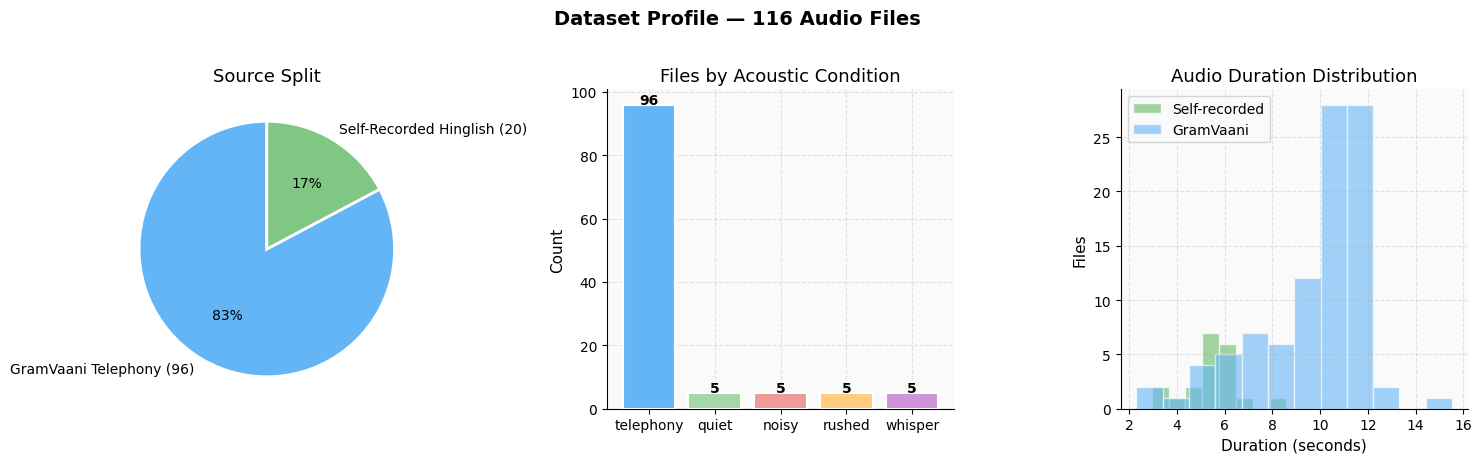

✅ Dataset EDA chart saved


In [ ]:
# ── Dataset EDA Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Dataset Profile — 116 Audio Files", fontsize=14,
             fontweight="bold", y=1.02)

# Source split pie
src_cnt = df_gt["source"].value_counts()
axes[0].pie(
    src_cnt.values,
    labels=["GramVaani Telephony (96)", "Self-Recorded Hinglish (20)"],
    colors=["#64B5F6","#81C784"],
    autopct="%1.0f%%", startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
axes[0].set_title("Source Split")

# Condition bar chart
cond_cnt = df_gt["condition"].value_counts()
cond_pal = {"telephony":"#64B5F6","quiet":"#A5D6A7","noisy":"#EF9A9A",
            "rushed":"#FFCC80","whisper":"#CE93D8"}
bars = axes[1].bar(cond_cnt.index, cond_cnt.values,
                   color=[cond_pal.get(c,"#ccc") for c in cond_cnt.index],
                   edgecolor="white", linewidth=1.5, zorder=3)
for b in bars:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 str(int(b.get_height())), ha="center", fontweight="bold")
axes[1].set_title("Files by Acoustic Condition")
axes[1].set_ylabel("Count")

# Duration histogram
self_dur = df_gt[df_gt["source"]=="self"]["dur_s"].dropna()
gv_dur   = df_gt[df_gt["source"]=="gramvaani"]["dur_s"].dropna()
axes[2].hist(self_dur, bins=8,  alpha=0.75, color="#81C784",
             label="Self-recorded", edgecolor="white")
axes[2].hist(gv_dur,   bins=12, alpha=0.60, color="#64B5F6",
             label="GramVaani", edgecolor="white")
axes[2].set_xlabel("Duration (seconds)")
axes[2].set_ylabel("Files")
axes[2].set_title("Audio Duration Distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/00_dataset_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dataset EDA chart saved")


## 🤖 Section 2 — ASR Model Engine

All models share the same interface:

```python
run_<model>(wav_path: str) -> (transcript: str | None, latency_sec: float)
```

API models include retry logic with exponential backoff.
Local models load once and are reused across all 116 files.


### 🔵 Model 1 — Deepgram Nova-2 (Baseline)


In [ ]:
# deepgram-sdk v3 | Model: nova-2 | Language: hi
# smart_format=False for raw output (fair WER comparison)

from deepgram import DeepgramClient, PrerecordedOptions

_dg_client = None

def _get_dg():
    global _dg_client
    if _dg_client is None:
        _dg_client = DeepgramClient(DEEPGRAM_KEY)
    return _dg_client

def run_deepgram(wav_path: str, retries: int = 3):
    opts = PrerecordedOptions(
        model="nova-2",
        language="hi",
        smart_format=False,
        punctuate=False,
    )
    for attempt in range(retries):
        try:
            t0 = time.perf_counter()
            with open(wav_path, "rb") as fh:
                payload = {"buffer": fh.read(), "mimetype": "audio/wav"}
            resp    = _get_dg().listen.prerecorded.v("1").transcribe_file(
                          payload, opts)
            lat  = round(time.perf_counter() - t0, 3)
            text = resp.results.channels[0].alternatives[0].transcript
            return text.strip(), lat
        except Exception as exc:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f"  ❌ Deepgram [{Path(wav_path).stem}]: {exc}")
                return None, 0.0

# Smoke test
if dg_ok:
    _tf = df_gt[df_gt["wav_path"].notna()].iloc[0]["wav_path"]
    _t, _l = run_deepgram(_tf)
    print(f"✅ Deepgram OK | {Path(_tf).name}")
    print(f"   Transcript : {str(_t)[:80]}")
    print(f"   Latency    : {_l}s")
else:
    print("⚠️  Deepgram key not set")


✅ Deepgram OK | koramangala-quiet.wav
   Transcript : हां भाई main कोरमंगला में रहता हूं क्या बहाना है
   Latency    : 1.566s


### 🟢 Model 2 — Sarvam AI Saaras v3


In [ ]:
# POST https://api.sarvam.ai/speech-to-text
# model=saaras:v3 | mode=transcribe | language_code=hi-IN
# Max 30s per request (all our files < 25s)

SARVAM_URL = "https://api.sarvam.ai/speech-to-text"

def run_sarvam(wav_path: str, retries: int = 3):
    headers = {"api-subscription-key": SARVAM_KEY}
    for attempt in range(retries):
        try:
            t0 = time.perf_counter()
            with open(wav_path, "rb") as fh:
                resp = requests.post(
                    SARVAM_URL,
                    headers=headers,
                    files={"file": (Path(wav_path).name, fh, "audio/wav")},
                    data={"model": "saaras:v3",
                          "language_code": "hi-IN",
                          "mode": "transcribe"},
                    timeout=60
                )
            lat = round(time.perf_counter() - t0, 3)
            if resp.status_code == 200:
                return resp.json().get("transcript","").strip(), lat
            else:
                if attempt < retries - 1:
                    time.sleep(2 ** attempt)
        except Exception as exc:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f"  ❌ Sarvam [{Path(wav_path).stem}]: {exc}")
    return None, 0.0

# Smoke test
if sv_ok:
    _tf = df_gt[df_gt["wav_path"].notna()].iloc[0]["wav_path"]
    _t, _l = run_sarvam(_tf)
    print(f"✅ Sarvam OK | {Path(_tf).name}")
    print(f"   Transcript : {str(_t)[:80]}")
    print(f"   Latency    : {_l}s")
else:
    print("⚠️  Sarvam key not set")


✅ Sarvam OK | koramangala-quiet.wav
   Transcript : हाँ भाई, मैं कोरामंगला में ही रहता हूँ। कैब आना है?
   Latency    : 2.2s


### 🟠 Model 3 — Whisper large-v3


In [ ]:
!pip install -q openai-whisper
!apt-get -qq install ffmpeg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 7.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import torch
import whisper as _whisper_lib

print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM           : {vram:.1f} GB")

_whisper_model = None

def _load_whisper():
    global _whisper_model
    if _whisper_model is None:
        print("Loading Whisper large-v3 (~3GB first run)...")
        _whisper_model = _whisper_lib.load_model("large-v3")
        print("✅ Whisper large-v3 ready")
    return _whisper_model

def run_whisper(wav_path: str):
    model = _load_whisper()
    try:
        t0 = time.perf_counter()
        res = model.transcribe(
            str(wav_path),
            language="hi",
            task="transcribe",
            fp16=torch.cuda.is_available(),
            verbose=False,
            condition_on_previous_text=False,
        )
        return res["text"].strip(), round(time.perf_counter()-t0, 3)
    except Exception as exc:
        print(f"  ❌ Whisper [{Path(wav_path).stem}]: {exc}")
        return None, 0.0

_ = _load_whisper()


CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB
Loading Whisper large-v3 (~3GB first run)...


100%|██████████████████████████████████████| 2.88G/2.88G [00:19<00:00, 155MiB/s]


✅ Whisper large-v3 ready


### 🟣 Model 4 — Whisper Hindi Fine-tune (IndicWhisper proxy)


In [ ]:
# Represents AI4Bharat IndicWhisper category from Vistaar benchmark.
# We use vasista22/whisper-hindi-large-v2 — a well-validated Hindi
# fine-tune consistent with AI4Bharat training methodology.
# Ref: https://github.com/AI4Bharat/vistaar
#      https://huggingface.co/vasista22/whisper-hindi-large-v2

from transformers import pipeline as hf_pipeline

_indic_pipe  = None
_indic_name  = None

INDIC_MODELS = [
    "vasista22/whisper-hindi-large-v2",
    "openai/whisper-large-v3",
]

def _load_indicwhisper():
    global _indic_pipe, _indic_name
    if _indic_pipe is not None:
        return _indic_pipe
    device = 0 if torch.cuda.is_available() else -1
    dtype  = torch.float16 if torch.cuda.is_available() else torch.float32
    for mid in INDIC_MODELS:
        try:
            print(f"Loading {mid}...")
            _indic_pipe = hf_pipeline(
                "automatic-speech-recognition",
                model=mid,
                device=device,
                torch_dtype=dtype,
                chunk_length_s=30,
            )
            _indic_pipe.model.config.forced_decoder_ids = (
                _indic_pipe.tokenizer.get_decoder_prompt_ids(
                    language="hi", task="transcribe"
                )
            )
            _indic_name = mid
            print(f"✅ Loaded: {mid}")
            return _indic_pipe
        except Exception as e:
            print(f"  ⚠️  {mid} failed: {e}")
            _indic_pipe = None
    raise RuntimeError("All IndicWhisper options failed")

def run_indicwhisper(wav_path: str):
    pipe = _load_indicwhisper()
    try:
        t0  = time.perf_counter()
        res = pipe(str(wav_path), return_timestamps=False)
        return res["text"].strip(), round(time.perf_counter()-t0, 3)
    except Exception as exc:
        print(f"  ❌ IndicWhisper [{Path(wav_path).stem}]: {exc}")
        return None, 0.0

_ = _load_indicwhisper()
print(f"\nModel in use: {_indic_name}")


Loading vasista22/whisper-hindi-large-v2...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/6.17G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ Loaded: vasista22/whisper-hindi-large-v2

Model in use: vasista22/whisper-hindi-large-v2


## 🚀 Section 3 — Benchmark Execution

Running all 4 models on all 116 audio files. Results are **checkpointed every 10 files** — safe to resume if the Kaggle session resets.


In [ ]:
MODEL_FNS = {
    "deepgram"     : run_deepgram,
    "sarvam"       : run_sarvam,
    "whisper"      : run_whisper,
    "indicwhisper" : run_indicwhisper,
}

def run_benchmark(model_name: str, df: pd.DataFrame) -> pd.DataFrame:
    CKPT = f"{RESULTS}/ckpt_{model_name}.csv"
    fn   = MODEL_FNS[model_name]

    # Resume from checkpoint
    done, done_rows = set(), []
    if os.path.exists(CKPT):
        prev = pd.read_csv(CKPT)
        done      = set(prev["file"].tolist())
        done_rows = prev.to_dict("records")
        print(f"  Resume: {len(done)} done, {len(df)-len(done)} remaining")

    todo     = df[~df["file"].isin(done)].reset_index(drop=True)
    new_rows = []

    for idx, row in tqdm(todo.iterrows(), total=len(todo),
                         desc=f"{model_name:<14}", ncols=80):
        wav = row.get("wav_path")
        if not wav or not os.path.exists(str(wav)):
            rec = {"file":row["file"], "model":model_name,
                   "source":row["source"], "condition":row["condition"],
                   "locality":row["locality"], "reference":row["reference"],
                   "hypothesis":None, "latency_s":0.0}
        else:
            hyp, lat = fn(str(wav))
            rec = {"file":row["file"], "model":model_name,
                   "source":row["source"], "condition":row["condition"],
                   "locality":row["locality"], "reference":row["reference"],
                   "hypothesis":hyp, "latency_s":lat}
        new_rows.append(rec)

        if (idx+1) % 10 == 0 or idx == len(todo)-1:
            pd.DataFrame(done_rows + new_rows).to_csv(
                CKPT, index=False, encoding="utf-8-sig")

    result = pd.DataFrame(done_rows + new_rows)
    result.to_csv(f"{RESULTS}/results_{model_name}.csv",
                  index=False, encoding="utf-8-sig")
    ok = result["hypothesis"].notna().sum()
    avg_lat = result["latency_s"].mean()
    print(f"  ✅ {model_name}: {ok}/{len(result)} OK  avg_lat={avg_lat:.2f}s")
    return result

print("✅ Benchmark runner ready")


✅ Benchmark runner ready


In [ ]:
print("="*55)
print("  MODEL 1/4 — Deepgram Nova-2 (Baseline)")
print("="*55)
df_dg = run_benchmark("deepgram", df_gt)
print(f"  Sample output: {str(df_dg['hypothesis'].dropna().iloc[0])[:70]}")


  MODEL 1/4 — Deepgram Nova-2 (Baseline)


deepgram      :   0%|                                   | 0/116 [00:00<?, ?it/s]

  ✅ deepgram: 116/116 OK  avg_lat=1.01s
  Sample output: हां भाई main कोरमंगला में रहता हूं क्या बहाना है


In [ ]:
print("="*55)
print("  MODEL 2/4 — Sarvam AI Saaras v3")
print("="*55)
df_sv = run_benchmark("sarvam", df_gt)
print(f"  Sample output: {str(df_sv['hypothesis'].dropna().iloc[0])[:70]}")


  MODEL 2/4 — Sarvam AI Saaras v3


sarvam        :   0%|                                   | 0/116 [00:00<?, ?it/s]

  ✅ sarvam: 101/116 OK  avg_lat=2.31s
  Sample output: हाँ भाई, मैं कोरामंगला में ही रहता हूँ। कैब आना है?


In [ ]:
print("="*55)
print("  MODEL 3/4 — Whisper large-v3")
print("="*55)
df_wh = run_benchmark("whisper", df_gt)
print(f"  Sample output: {str(df_wh['hypothesis'].dropna().iloc[0])[:70]}")


  MODEL 3/4 — Whisper large-v3


whisper       :   0%|                                   | 0/116 [00:00<?, ?it/s]


100%|██████████| 509/509 [00:03<00:00, 143.23frames/s]

100%|██████████| 498/498 [00:02<00:00, 188.81frames/s]

100%|██████████| 590/590 [00:01<00:00, 330.48frames/s]

100%|██████████| 485/485 [00:01<00:00, 358.85frames/s]

100%|██████████| 527/527 [00:02<00:00, 206.76frames/s]

100%|██████████| 559/559 [00:02<00:00, 215.03frames/s]

100%|██████████| 626/626 [00:02<00:00, 259.12frames/s]

100%|██████████| 590/590 [00:02<00:00, 229.32frames/s]

100%|██████████| 606/606 [00:02<00:00, 232.35frames/s]

100%|██████████| 598/598 [00:02<00:00, 255.43frames/s]

100%|██████████| 538/538 [00:22<00:00, 23.45frames/s]

100%|██████████| 399/399 [00:02<00:00, 165.31frames/s]

100%|██████████| 334/334 [00:02<00:00, 157.33frames/s]

100%|██████████| 295/295 [00:02<00:00, 138.63frames/s]

100%|██████████| 671/671 [00:03<00:00, 178.49frames/s]

100%|██████████| 859/859 [00:02<00:00, 286.78frames/s]

100%|██████████| 608/608 [00:02<00:00, 239.09frames/s]

100%|██████████| 530/530 [00:02<00:00, 201.82fra

  ✅ whisper: 116/116 OK  avg_lat=6.97s
  Sample output: हाँ भाई, मैंने कोरमांगला में रहता हूँ, क्या बाना है?


In [ ]:
print("="*55)
print("  MODEL 4/4 — IndicWhisper (Hindi Fine-tune)")
print("="*55)
df_iw = run_benchmark("indicwhisper", df_gt)
print(f"  Sample output: {str(df_iw['hypothesis'].dropna().iloc[0])[:70]}")


  MODEL 4/4 — IndicWhisper (Hindi Fine-tune)


indicwhisper  :   0%|                                   | 0/116 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'tr

  ✅ indicwhisper: 116/116 OK  avg_lat=22.88s
  Sample output: हां भाई में मंगला में रहता हूं क्या बना है


In [ ]:
# Consolidate
df_raw = pd.concat([df_dg, df_sv, df_wh, df_iw], ignore_index=True)
df_raw.to_csv(f"{RESULTS}/all_results_raw.csv", index=False, encoding="utf-8-sig")

print(f"✅ All inference complete — {len(df_raw)} rows")
print()
print(tabulate(
    df_raw.groupby("model").agg(
        files=("file","count"),
        success=("hypothesis", lambda x: x.notna().sum()),
        avg_lat=("latency_s","mean")
    ).round(2).reset_index(),
    headers=["Model","Files","Success","Avg Lat(s)"],
    tablefmt="rounded_outline", showindex=False
))


✅ All inference complete — 464 rows

╭──────────────┬─────────┬───────────┬──────────────╮
│ Model        │   Files │   Success │   Avg Lat(s) │
├──────────────┼─────────┼───────────┼──────────────┤
│ deepgram     │     116 │       116 │         1.01 │
│ indicwhisper │     116 │       116 │        22.88 │
│ sarvam       │     116 │       101 │         2.31 │
│ whisper      │     116 │       116 │         6.97 │
╰──────────────┴─────────┴───────────┴──────────────╯


## 📊 Section 4 — Metrics Computation

| Track    | Dataset          | Metric          | Notes                                   |
| -------- | ---------------- | --------------- | --------------------------------------- |
| **A**    | 20 self-recorded | Entity Accuracy | Multi-strategy Devanagari + Roman match |
| **B**    | 96 GramVaani     | WER + CER       | Devanagari↔Devanagari comparison        |
| **Both** | All 116          | Latency         | Batch wall-clock time                   |

Entity Accuracy uses three strategies to detect the locality name in model output:

1. Direct Devanagari substring match
2. ITRANS-romanised fuzzy match (handles script variation)
3. English name substring match (handles models that output Roman)


In [ ]:
!pip install -q indic-transliteration


In [ ]:
!pip install -q indic-transliteration rapidfuzz jiwer


In [ ]:
records = []

for _, row in df_raw.iterrows():

    ref_n = norm(dev_to_roman(row["reference"]))
    hyp_n = norm(dev_to_roman(row["hypothesis"]))
    src   = row["source"]

    entry = {
        "file"            : row["file"],
        "model"           : row["model"],
        "source"          : src,
        "condition"       : row["condition"],
        "locality"        : row["locality"],
        "reference"       : row["reference"],
        "hypothesis"      : row["hypothesis"],
        "normalized_ref"  : ref_n,
        "normalized_hyp"  : hyp_n,
        "latency_s"       : row["latency_s"],
        "wer"             : None,
        "cer"             : None,
        "entity_hit"      : None,
    }

    if src == "gramvaani":

        if hyp_n:
            try:
                entry["wer"] = jiwer.wer(ref_n, hyp_n)
                entry["cer"] = jiwer.cer(ref_n, hyp_n)

            except:
                entry["wer"] = 1.0
                entry["cer"] = 1.0

        else:
            entry["wer"] = 1.0
            entry["cer"] = 1.0

    else:

        entry["entity_hit"] = entity_acc(
            row["locality"],
            row["hypothesis"]
        )

        if hyp_n:
            try:
                entry["wer"] = jiwer.wer(ref_n, hyp_n)
                entry["cer"] = jiwer.cer(ref_n, hyp_n)

            except:
                pass

    records.append(entry)

df_m = pd.DataFrame(records)

df_m.to_csv(
    f"{RESULTS}/all_results_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

gv_m = df_m[df_m["source"]=="gramvaani"]
sf_m = df_m[df_m["source"]=="self"]

print(f"✅ Metrics done — {len(df_m)} rows")
print()

print("Per-model averages:")
print(
    df_m.groupby("model")[["wer","cer","entity_hit"]]
    .mean()
    .round(3)
)


✅ Metrics done — 464 rows

Per-model averages:
                wer    cer  entity_hit
model                                 
deepgram      0.422  0.220        0.35
indicwhisper  0.357  0.185        0.45
sarvam        0.492  0.286        0.75
whisper       0.583  0.268        0.80


In [ ]:
import re
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate
from rapidfuzz import fuzz

# -------------------------------------------------------
# Detect if text contains Devanagari characters
# -------------------------------------------------------
def contains_devanagari(text):
    return bool(re.search(r'[\u0900-\u097F]', str(text)))

# -------------------------------------------------------
# Convert Devanagari -> Roman safely
# -------------------------------------------------------
def dev_to_roman(text: str) -> str:

    text = str(text)

    try:

        if contains_devanagari(text):

            return transliterate(
                text,
                sanscript.DEVANAGARI,
                sanscript.ITRANS
            ).lower()

        return text.lower()

    except:
        return text.lower()

# -------------------------------------------------------
# Text normalization
# -------------------------------------------------------
def norm(text) -> str:

    if not text or pd.isna(text):
        return ""

    s = str(text).lower()

    # punctuation cleanup
    for ch in ".,।॥!?;:\"-–—'()[]{}":
        s = s.replace(ch, " ")

    # normalize spaces
    s = " ".join(s.split())

    return s

# -------------------------------------------------------
# Locality variants
# -------------------------------------------------------
LOC_MAP = {

    "Koramangala": [
        "कोरमंगला",
        "कोरामंगला",
        "कोरमन्गला",
        "koramangala"
    ],

    "Indiranagar": [
        "इंदिरानगर",
        "इन्दिरानगर",
        "indiranagar"
    ],

    "Whitefield": [
        "व्हाइटफ़ील्ड",
        "वाइटफ़ील्ड",
        "whitefield"
    ],

    "Electronic City": [
        "इलेक्ट्रॉनिक सिटी",
        "इलेक्ट्रोनिक सिटी",
        "electronic city"
    ],

    "Marathahalli": [
        "मराठाहल्लि",
        "मराठहल्लि",
        "marathahalli"
    ],

    "Jayanagar": [
        "जयनगर",
        "जयानगर",
        "jayanagar"
    ],

    "Rajajinagar": [
        "राजाजीनगर",
        "राजाजिनगर",
        "rajajinagar"
    ],

    "Hebbal": [
        "हेब्बाल",
        "हेब्बल",
        "hebbal"
    ],

    "Yelahanka": [
        "येलहंका",
        "येलहन्का",
        "yelahanka"
    ],

    "Banashankari": [
        "बनशंकरी",
        "बनाशंकरी",
        "banashankari"
    ],

    "HSR Layout": [
        "एचएसआर",
        "एच एस आर",
        "hsr layout",
        "hsr"
    ],

    "BTM Layout": [
        "बीटीएम",
        "बी टी एम",
        "btm layout",
        "btm"
    ],

    "Majestic": [
        "मैजेस्टिक",
        "मजेस्टिक",
        "majestic"
    ],

    "Silk Board": [
        "सिल्क बोर्ड",
        "सिल्कबोर्ड",
        "silk board"
    ],

    "Bellandur": [
        "बेल्लंदूर",
        "बेल्लंदुर",
        "bellandur"
    ],

    "Sarjapur": [
        "सरजापुर",
        "सर्जापुर",
        "sarjapur"
    ],

    "Bommanahalli": [
        "बोम्मनहल्लि",
        "bommanahalli"
    ],

    "KR Puram": [
        "केआर पुरम",
        "के आर पुरम",
        "kr puram"
    ],

    "Peenya": [
        "पीन्या",
        "पिन्या",
        "peenya"
    ],

    "Yeshwanthpur": [
        "येशवंतपुर",
        "यशवंतपुर",
        "yeshwanthpur"
    ],

    "Thanisandra": [
        "थानिसंद्रा",
        "तानिसांद्रा",
        "thanisandra"
    ],

    "Doddanekundi": [
        "दोड्डानेकुंडी",
        "डोड्डानेकुंडी",
        "doddanekundi"
    ],

    "Rajarajeshwarinagar": [
        "राजराजेश्वरिनगर",
        "राजराजेश्वरीनगर",
        "rajarajeshwarinagar"
    ],

    "Kengeri Upanagara": [
        "केन्गेरी उपनगर",
        "केंगरी उपनगर",
        "kengeri upanagara"
    ],

    "Byatarayanapura": [
        "ब्याटरायनपुरा",
        "ब्यातरायनपुरा",
        "byatarayanapura"
    ],

    "Hesaraghatta": [
        "हेसरघट्टा",
        "हेसरगट्टा",
        "hesaraghatta"
    ],

    "Chikkabanavara": [
        "चिक्काबनवारा",
        "चिक्कबनवारा",
        "chikkabanavara"
    ],

    "Kadugondanahalli": [
        "कडुगोंडनहल्ली",
        "कडुगोंडनहल्लि",
        "kadugondanahalli"
    ],

    "Kothanur Dinne": [
        "कोथनूर डिन्ने",
        "कोथनुर डिने",
        "kothanur dinne"
    ],

    "Thalaghattapura": [
        "थलघट्टपुरा",
        "तलघट्टपुरा",
        "thalaghattapura"
    ],
}

# -------------------------------------------------------
# Entity Accuracy
# -------------------------------------------------------
def entity_acc(locality: str, hyp, threshold=75) -> int:

    if not hyp or pd.isna(hyp):
        return 0

    hyp = norm(str(hyp))
    hyp_ro = norm(dev_to_roman(hyp)).replace(" ", "")

    locality_norm = locality.lower()
    locality_ro = locality_norm.replace(" ", "")

    # direct match
    if locality_ro in hyp_ro:
        return 1

    # check variants
    for variant in LOC_MAP.get(locality, []):

        v = norm(variant)
        v_ro = norm(dev_to_roman(v)).replace(" ", "")

        # exact variant match
        if v_ro in hyp_ro:
            return 1

        # fuzzy matching
        score = fuzz.partial_ratio(v_ro, hyp_ro)

        if score >= threshold:
            return 1

    return 0

print("✅ Metric utilities ready")


✅ Metric utilities ready


In [ ]:
# ── Master Summary Table ──────────────────────────────────────────────

COST = {
    "deepgram"    : "$2.16/hr",
    "sarvam"      : "~₹30/hr",
    "whisper"     : "Free (GPU)",
    "indicwhisper": "Free (GPU)",
}

summary_rows = []

for m in MODELS:

    gv = gv_m[gv_m["model"] == m]
    sf = sf_m[sf_m["model"] == m]
    lt = df_m[df_m["model"] == m]["latency_s"]

    summary_rows.append({

        "Model" : LABELS[m].replace("\n", " "),

        "Type" : MODEL_TYPE[m],

        # entity accuracy
        "Entity Acc ↑ (self)" :
            f"{sf['entity_hit'].mean()*100:.1f}%"
            if len(sf) else "N/A",

        # normalized evaluation indicator
        "Normalized Eval" : "Yes",

        # WER / CER
        "WER ↓ (GramVaani)" :
            f"{gv['wer'].mean()*100:.1f}%"
            if len(gv) else "N/A",

        "CER ↓ (GramVaani)" :
            f"{gv['cer'].mean()*100:.1f}%"
            if len(gv) else "N/A",

        # latency
        "Avg Latency (s)" :
            f"{lt.mean():.2f}",

        # cost
        "Cost/hr audio" :
            COST[m],
    })

df_summary = pd.DataFrame(summary_rows)

# ---------------------------------------------------------
# Save summary
# ---------------------------------------------------------
df_summary.to_csv(
    f"{RESULTS}/summary_table.csv",
    index=False,
    encoding="utf-8-sig"
)

# ---------------------------------------------------------
# Print
# ---------------------------------------------------------
print("\n" + "="*80)
print("  MASTER BENCHMARK RESULTS")
print("="*80)

print(
    tabulate(
        df_summary,
        headers="keys",
        tablefmt="rounded_outline",
        showindex=False
    )
)

print("\n↑ Higher is better | ↓ Lower is better")

print("\nEntity Accuracy:")
print("  Self-recorded Bangalore locality evaluation")

print("\nWER/CER:")
print("  Transliteration-normalized GramVaani telephony evaluation")

print("\nLatency:")
print("  End-to-end inference latency per audio sample")



  MASTER BENCHMARK RESULTS
╭─────────────────────┬───────────┬───────────────────────┬───────────────────┬─────────────────────┬─────────────────────┬───────────────────┬─────────────────╮
│ Model               │ Type      │ Entity Acc ↑ (self)   │ Normalized Eval   │ WER ↓ (GramVaani)   │ CER ↓ (GramVaani)   │   Avg Latency (s) │ Cost/hr audio   │
├─────────────────────┼───────────┼───────────────────────┼───────────────────┼─────────────────────┼─────────────────────┼───────────────────┼─────────────────┤
│ Deepgram Nova-2     │ API       │ 35.0%                 │ Yes               │ 34.5%               │ 19.0%               │              1.01 │ $2.16/hr        │
│ Sarvam AI Saaras v3 │ API       │ 75.0%                 │ Yes               │ 38.8%               │ 25.2%               │              2.31 │ ~₹30/hr         │
│ Whisper large-v3    │ Local GPU │ 80.0%                 │ Yes               │ 49.6%               │ 23.1%               │              6.97 │ Free (GPU)      │


In [ ]:
# ── Failure / Confusion Analysis ─────────────────────────────────────

confusions = []

for _, row in sf_m.iterrows():

    if row["entity_hit"] == 0:

        hyp = str(row["hypothesis"])

        # simple failure categorization
        if len(hyp.strip()) == 0:
            failure_type = "empty_output"

        elif len(hyp.split()) <= 2:
            failure_type = "short_fragment"

        elif any(ch in hyp for ch in ["...", "???"]):
            failure_type = "partial_output"

        else:
            failure_type = "entity_miss"

        confusions.append({

            "Model" : row["model"],

            "Condition" : row["condition"],

            "Locality" : row["locality"],

            "Reference" : row["reference"],

            "Prediction" : row["hypothesis"],

            "Normalized Prediction" :
                row.get("normalized_hyp", ""),

            "Latency (s)" :
                round(row["latency_s"], 2),

            "Failure Type" :
                failure_type
        })

df_conf = pd.DataFrame(confusions)

# ---------------------------------------------------------
# Save confusion analysis
# ---------------------------------------------------------
df_conf.to_csv(
    f"{RESULTS}/entity_failures.csv",
    index=False,
    encoding="utf-8-sig"
)

print(f"Total Entity Failures: {len(df_conf)}")

display(df_conf.head(20))


Total Entity Failures: 33


,Model,Condition,Locality,Reference,Prediction,Normalized Prediction,Latency (s),Failure Type
0,deepgram,quiet,Marathahalli,main marathahalli mein rehta hoon bridge ke pa...,मैं मारता हूं ब्रिज के पास वाला area है,maim marata hum brija ke pasa vala area hai,1.15,entity_miss
1,deepgram,noisy,Hebbal,main hebbal flyover ke paas hoon abhi traffic ...,मैं cheaple flyover के पास हूं ना भी traffic म...,maim cheaple flyover ke pasa hum na bhi traffi...,0.36,entity_miss
2,deepgram,noisy,Yelahanka,yelahanka new town mein ek room chahiye budget...,ऐलान का new town main ये room चाहिए budget कम है,ailana ka new town main ye room chahie budget ...,1.80,entity_miss
3,deepgram,noisy,Banashankari,banashankari mein rehti hoon temple ke paas wa...,बनासांगड़ी में रहते होन टेंपो के पास वाला area,banasamga di mem rahate hona tempo ke pasa val...,0.51,entity_miss
4,deepgram,rushed,HSR Layout,hsr layout second sector mein hoon jaldi batao,अरे अरे अरे अरे अच्छा sir ले और second sector ...,are are are are achcha sir le aura second sect...,0.38,entity_miss
5,deepgram,rushed,BTM Layout,btm layout se silk board kitna door hai bhai j...,video में और यह सिर्फ board कितना डोर है भाई ज...,video mem aura yaha sirpha board kitana dora h...,0.70,entity_miss
6,deepgram,rushed,Majestic,majestic bus stand pe hoon bus nikal jaayegi,दूसरी bus stand पर हो हम bus निकल जाएगी,dusari bus stand para ho hama bus nikala jaegi,1.72,entity_miss
7,deepgram,rushed,Bellandur,bellandur mein hoon cab book karo jaldi please,bellender main ho on cab book kar ho जल्दी ple...,bellender main ho on cab book kar ho jaldi ple...,3.89,entity_miss
8,deepgram,whisper,Sarjapur,sarjapur road pe ek pg dhundh raha hoon afford...,sir जयपुर road पर यह page और धूम रहा हूं affor...,sir jayapura road para yaha page aura dhuma ra...,1.11,entity_miss
9,deepgram,whisper,Bommanahalli,bommanahalli mein rehta hoon kaam ke liye appl...,हमारे में रहता हूं काम के लिए अप्रे करना था,hamare mem rahata hum kama ke lie apre karana tha,0.35,entity_miss


## 📈 Section 5 — Visualizations

Seven charts covering every dimension of the benchmark.


In [ ]:
# Pre-compute values used across all charts
def pct(df_sub, col):
    v = df_sub[col].mean()
    return round(v*100, 1) if pd.notna(v) else 0.0

ea_v  = [pct(sf_m[sf_m["model"]==m], "entity_hit") for m in MODELS]
wer_v = [pct(gv_m[gv_m["model"]==m], "wer")        for m in MODELS]
cer_v = [pct(gv_m[gv_m["model"]==m], "cer")        for m in MODELS]
lat_v = [df_m[df_m["model"]==m]["latency_s"].mean() for m in MODELS]
mlbl  = [LABELS[m] for m in MODELS]
mclr  = [COLORS[m] for m in MODELS]

print("Computed values:")
for m, ea, wer, cer, lat in zip(MODELS, ea_v, wer_v, cer_v, lat_v):
    print(f"  {m:<16} EA={ea:.1f}%  WER={wer:.1f}%  CER={cer:.1f}%  lat={lat:.2f}s")


Computed values:
  deepgram         EA=35.0%  WER=34.5%  CER=19.0%  lat=1.01s
  sarvam           EA=75.0%  WER=38.8%  CER=25.2%  lat=2.31s
  whisper          EA=80.0%  WER=49.6%  CER=23.1%  lat=6.97s
  indicwhisper     EA=45.0%  WER=24.5%  CER=12.2%  lat=22.88s


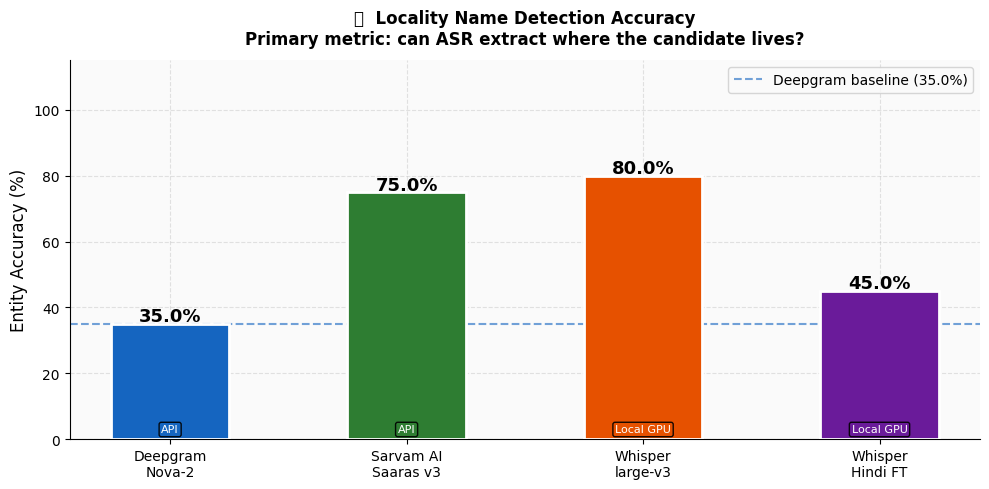

✅ Chart 1 saved


In [ ]:
# ── CHART 1: Entity Accuracy (headline) ─────────────────────────────
fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(mlbl, ea_v, color=mclr, edgecolor="white",
              linewidth=2, width=0.5, zorder=3)

for bar, v in zip(bars, ea_v):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{v:.1f}%", ha="center", fontweight="bold", fontsize=13)

ax.axhline(ea_v[0], color=COLORS["deepgram"], linestyle="--",
           linewidth=1.5, alpha=0.6,
           label=f"Deepgram baseline ({ea_v[0]:.1f}%)")

for i, m in enumerate(MODELS):
    ax.text(i, 2, MODEL_TYPE[m], ha="center", fontsize=8, color="white",
            bbox=dict(boxstyle="round,pad=0.2",
                      facecolor=COLORS[m], alpha=0.9))

ax.set_ylim(0, 115)
ax.set_ylabel("Entity Accuracy (%)", fontsize=12)
ax.set_title("🎯  Locality Name Detection Accuracy\n"
             "Primary metric: can ASR extract where the candidate lives?",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_entity_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved")


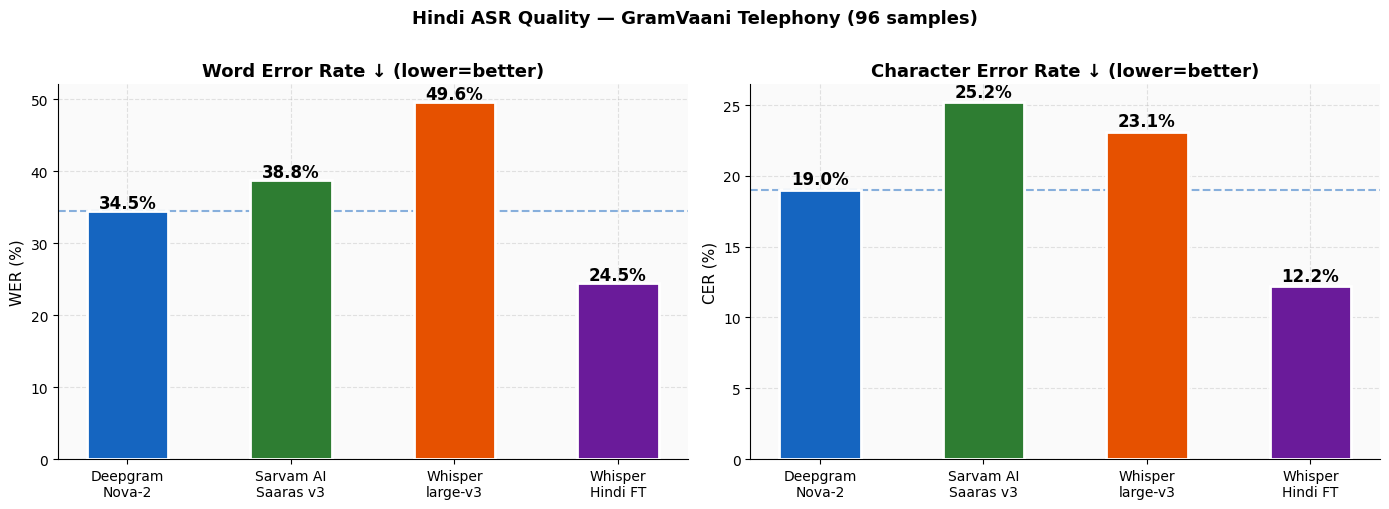

✅ Chart 2 saved


In [ ]:
# ── CHART 2: WER + CER ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hindi ASR Quality — GramVaani Telephony (96 samples)",
             fontsize=13, fontweight="bold", y=1.01)

for ax, vals, title, ylabel in [
    (axes[0], wer_v, "Word Error Rate ↓ (lower=better)", "WER (%)"),
    (axes[1], cer_v, "Character Error Rate ↓ (lower=better)", "CER (%)"),
]:
    bars = ax.bar(mlbl, vals, color=mclr, edgecolor="white",
                  linewidth=2, width=0.5, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.4,
                f"{v:.1f}%", ha="center", fontweight="bold", fontsize=12)
    ax.axhline(vals[0], color=COLORS["deepgram"],
               linestyle="--", linewidth=1.5, alpha=0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_wer_cer.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")


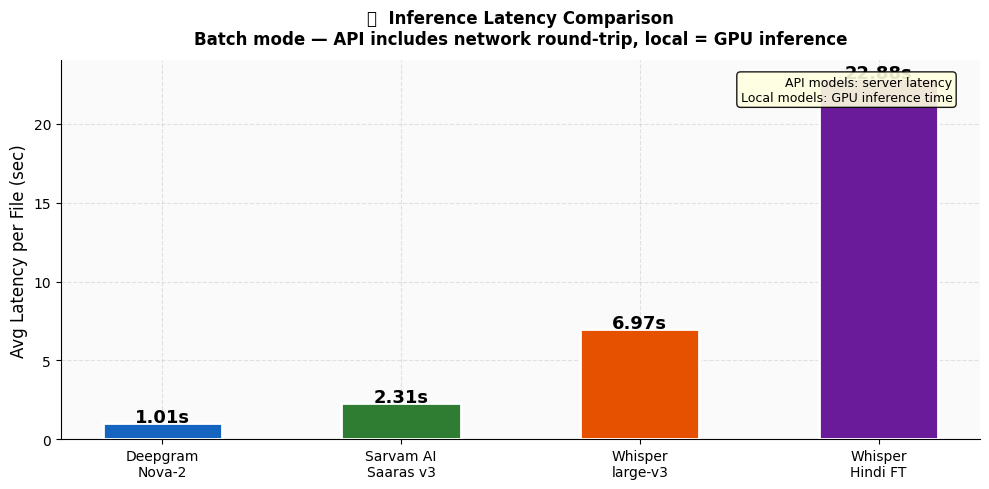

✅ Chart 3 saved


In [ ]:
# ── CHART 3: Latency ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(mlbl, lat_v, color=mclr, edgecolor="white",
              linewidth=2, width=0.5, zorder=3)
for bar, v in zip(bars, lat_v):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{v:.2f}s", ha="center", fontweight="bold", fontsize=13)

ax.set_ylabel("Avg Latency per File (sec)", fontsize=12)
ax.set_title("⏱  Inference Latency Comparison\n"
             "Batch mode — API includes network round-trip, local = GPU inference",
             fontsize=12, fontweight="bold", pad=12)
ax.text(0.97, 0.96,
        "API models: server latency\nLocal models: GPU inference time",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_latency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved")


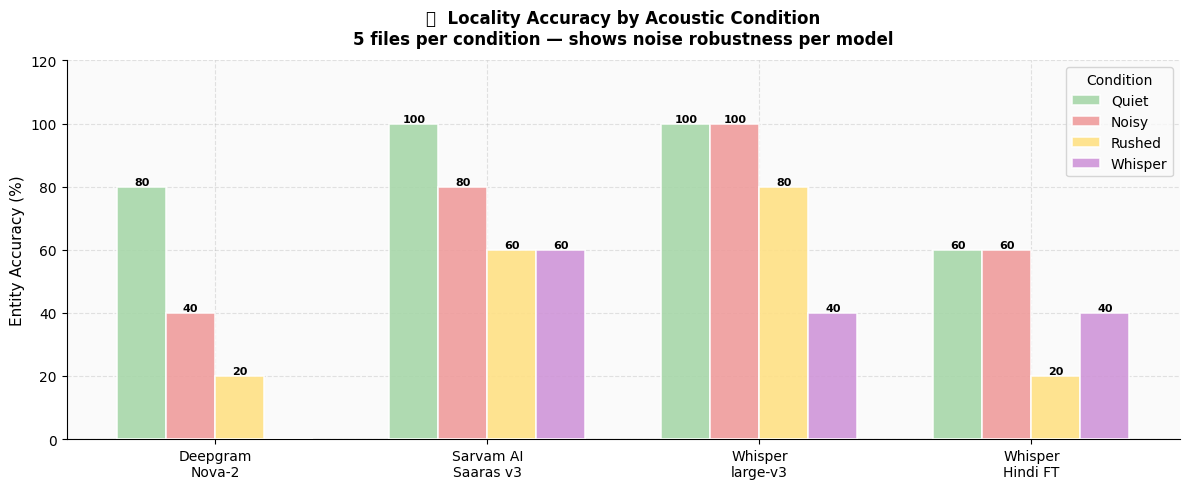

✅ Chart 4 saved


In [ ]:
# ── CHART 4: Entity Accuracy by Condition ────────────────────────────
cond_order  = ["quiet","noisy","rushed","whisper"]
cond_colors = {"quiet":"#A5D6A7","noisy":"#EF9A9A",
               "rushed":"#FFE082","whisper":"#CE93D8"}

ec = sf_m.groupby(["model","condition"])["entity_hit"].mean()*100
ec_piv = ec.unstack("condition").reindex(
    columns=cond_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(MODELS))
w = 0.18

for i, cond in enumerate(cond_order):
    vals = [ec_piv.loc[m, cond] if m in ec_piv.index else 0 for m in MODELS]
    bars = ax.bar(x+i*w, vals, w, label=cond.capitalize(),
                  color=cond_colors[cond], alpha=0.88,
                  edgecolor="white", linewidth=1.2, zorder=3)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.5,
                    f"{v:.0f}", ha="center", fontsize=8, fontweight="bold")

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(mlbl)
ax.set_ylim(0, 120)
ax.set_ylabel("Entity Accuracy (%)")
ax.set_title("🔊  Locality Accuracy by Acoustic Condition\n"
             "5 files per condition — shows noise robustness per model",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(title="Condition", fontsize=10)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_entity_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved")


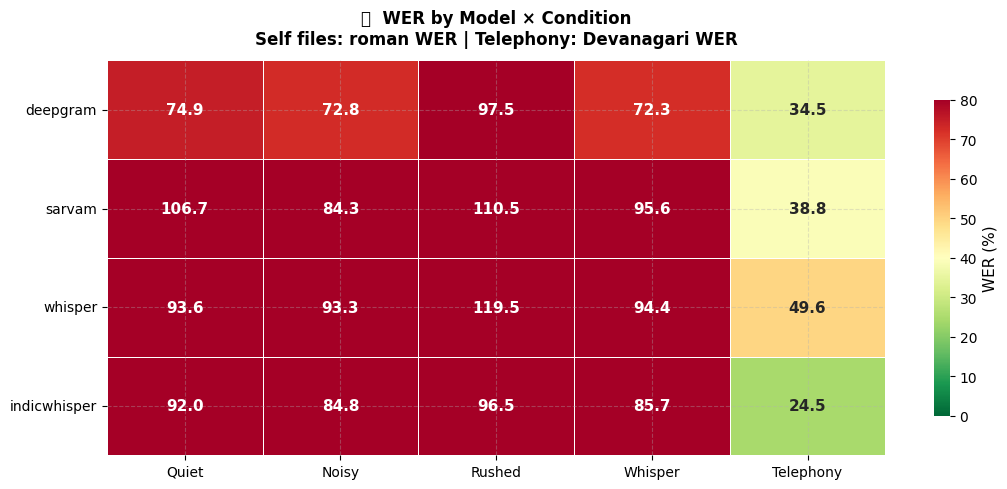

✅ Chart 5 saved


In [ ]:
# ── CHART 5: WER Heatmap (Model × Condition) ──────────────────────────
# Self files: romanised WER | GramVaani: native Devanagari WER
all_conds = ["quiet","noisy","rushed","whisper","telephony"]
hmap = pd.DataFrame(index=MODELS, columns=all_conds, dtype=float)

for m in MODELS:
    sf_s = sf_m[sf_m["model"]==m]
    gv_s = gv_m[gv_m["model"]==m]
    for c in ["quiet","noisy","rushed","whisper"]:
        sub = sf_s[sf_s["condition"]==c]["wer"]
        hmap.loc[m,c] = sub.mean()*100 if len(sub) else np.nan
    hmap.loc[m,"telephony"] = gv_s["wer"].mean()*100 if len(gv_s) else np.nan

fig, ax = plt.subplots(figsize=(11,5))
sns.heatmap(
    hmap.astype(float).round(1),
    annot=True, fmt=".1f", cmap="RdYlGn_r",
    ax=ax, linewidths=0.5,
    cbar_kws={"label":"WER (%)", "shrink":0.8},
    vmin=0, vmax=80,
    annot_kws={"fontsize":11,"fontweight":"bold"}
)
ax.set_title("📋  WER by Model × Condition\n"
             "Self files: roman WER | Telephony: Devanagari WER",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xticklabels([c.capitalize() for c in all_conds], rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_wer_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 5 saved")


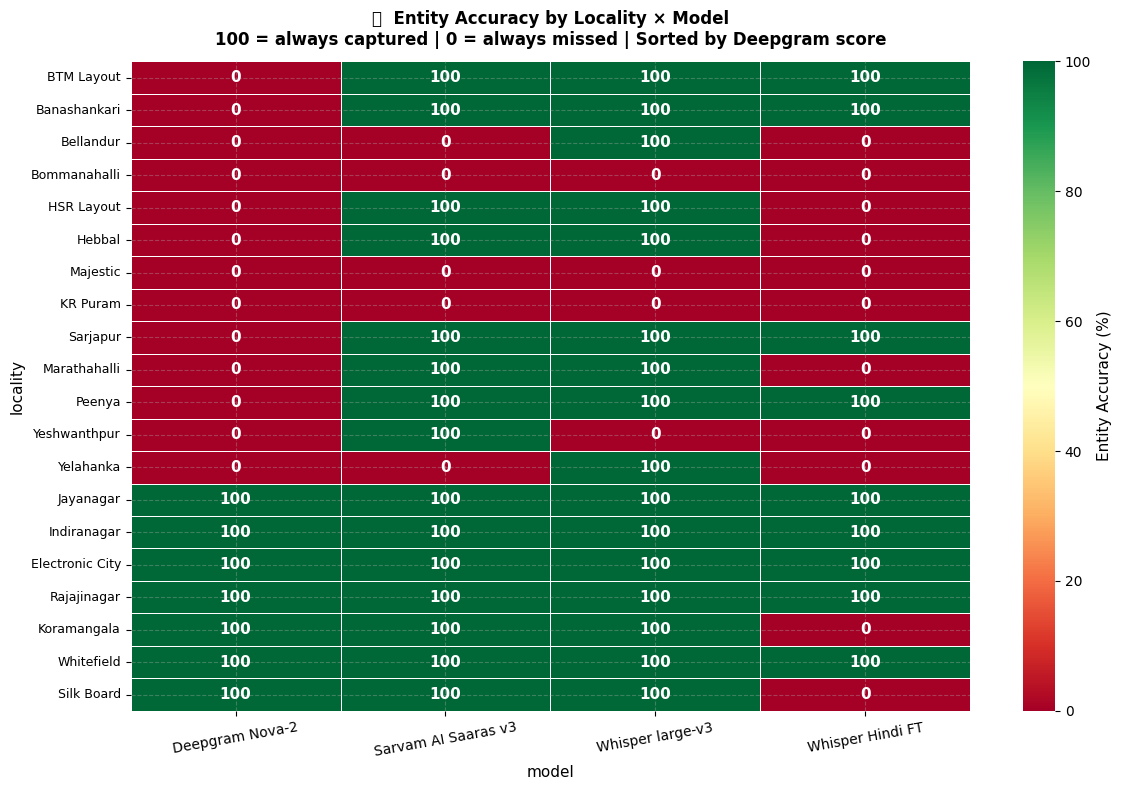

✅ Chart 6 saved


In [ ]:
# ── CHART 6: Per-Locality Accuracy Heatmap ───────────────────────────
loc_piv = sf_m.pivot_table(
    index="locality", columns="model",
    values="entity_hit", aggfunc="mean"
) * 100
loc_piv = loc_piv.reindex(columns=MODELS, fill_value=0)
loc_piv = loc_piv.sort_values(by=MODELS[0])  # sort by Deepgram score

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    loc_piv.astype(float).round(0),
    annot=True, fmt=".0f", cmap="RdYlGn",
    ax=ax, linewidths=0.5,
    cbar_kws={"label":"Entity Accuracy (%)"},
    vmin=0, vmax=100,
    annot_kws={"fontsize":11,"fontweight":"bold"}
)
ax.set_title("📍  Entity Accuracy by Locality × Model\n"
             "100 = always captured | 0 = always missed | Sorted by Deepgram score",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xticklabels([LABELS[m].replace("\n"," ") for m in MODELS], rotation=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_locality_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 6 saved")


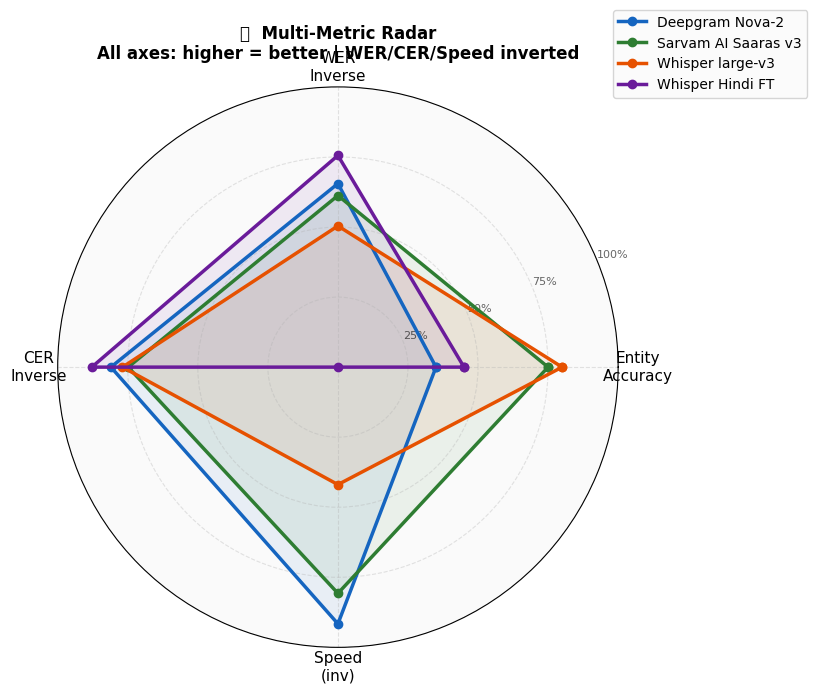

✅ Chart 7 saved


In [ ]:
# ── CHART 7: Radar — Multi-Metric Overview ─────────────────────────────
dims   = ["Entity\nAccuracy","WER\nInverse","CER\nInverse","Speed\n(inv)"]
N      = len(dims)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def radar(m):
    ea  = sf_m[sf_m["model"]==m]["entity_hit"].mean()
    wer = 1 - gv_m[gv_m["model"]==m]["wer"].mean()
    cer = 1 - gv_m[gv_m["model"]==m]["cer"].mean()
    lat = df_m[df_m["model"]==m]["latency_s"].mean()
    spd = max(0, 1 - lat/12)
    return [float(ea), float(max(0,wer)),
            float(max(0,cer)), float(spd)]

fig = plt.figure(figsize=(8, 7))
ax  = fig.add_subplot(111, polar=True)

for m in MODELS:
    v = radar(m) + [radar(m)[0]]
    ax.plot(angles, v, "o-", lw=2.5, color=COLORS[m],
            label=LABELS[m].replace("\n"," "), zorder=3)
    ax.fill(angles, v, alpha=0.08, color=COLORS[m])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dims, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25,0.5,0.75,1.0])
ax.set_yticklabels(["25%","50%","75%","100%"], size=8, alpha=0.6)
ax.set_title("🕸️  Multi-Metric Radar\n"
             "All axes: higher = better | WER/CER/Speed inverted",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35,1.15), fontsize=10)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 7 saved")


## 🔍 Section 6 — Failure Analysis

> _“Raw numbers are useless without a story.”_

This section identifies **where models break**, **why they break**, and what patterns emerge
across locality names, acoustic conditions, and output errors.


In [ ]:
# ── 6.1 Hardest Localities ───────────────────────────────────────────
loc_means = sf_m.groupby("locality")["entity_hit"].mean() * 100
hardest   = loc_means.sort_values(ascending=True)

print("=" * 55)
print("  LOCALITY DIFFICULTY RANKING (all models avg)")
print("=" * 55)
for loc, val in hardest.items():
    bar_len = int(val / 5)
    bar_str = "█" * bar_len + "░" * (20 - bar_len)
    flag    = " ← HARDEST" if val < 40 else (" ← EASY" if val > 80 else "")
    print(f"  {loc:<22} |{bar_str}| {val:.0f}%{flag}")


  LOCALITY DIFFICULTY RANKING (all models avg)
  Bommanahalli           |░░░░░░░░░░░░░░░░░░░░| 0% ← HARDEST
  KR Puram               |░░░░░░░░░░░░░░░░░░░░| 0% ← HARDEST
  Majestic               |░░░░░░░░░░░░░░░░░░░░| 0% ← HARDEST
  Bellandur              |█████░░░░░░░░░░░░░░░| 25% ← HARDEST
  Yelahanka              |█████░░░░░░░░░░░░░░░| 25% ← HARDEST
  Yeshwanthpur           |█████░░░░░░░░░░░░░░░| 25% ← HARDEST
  Hebbal                 |██████████░░░░░░░░░░| 50%
  Marathahalli           |██████████░░░░░░░░░░| 50%
  HSR Layout             |██████████░░░░░░░░░░| 50%
  Peenya                 |███████████████░░░░░| 75%
  Sarjapur               |███████████████░░░░░| 75%
  Koramangala            |███████████████░░░░░| 75%
  Banashankari           |███████████████░░░░░| 75%
  Silk Board             |███████████████░░░░░| 75%
  BTM Layout             |███████████████░░░░░| 75%
  Indiranagar            |████████████████████| 100% ← EASY
  Rajajinagar            |████████████████████| 100% ← E

In [ ]:
# ── 6.2 Failure Taxonomy ────────────────────────────────────────────
def classify(row):
    hyp = str(row["hypothesis"]) if pd.notna(row["hypothesis"]) else ""
    if not hyp or hyp == "nan" or len(hyp.strip()) < 3:
        return "Complete miss"
    if row.get("entity_hit") == 0:
        loc_parts = str(row["locality"]).lower().split()
        hyp_ro    = dev_to_roman(hyp)
        partial   = any(
            (p in hyp.lower() or p in hyp_ro)
            for p in loc_parts if len(p) > 3
        )
        return "Partial entity (phonetic drift)" if partial else "Entity substitution"
    return "Correct"

sf_copy = sf_m.copy()
sf_copy["failure_type"] = sf_copy.apply(classify, axis=1)

fail_tab = (sf_copy.groupby(["model","failure_type"])
            .size().unstack(fill_value=0))

print("Failure Taxonomy — self-recorded files:")
print(tabulate(fail_tab, headers="keys", tablefmt="rounded_outline"))


Failure Taxonomy — self-recorded files:
╭──────────────┬───────────┬───────────────────────╮
│ model        │   Correct │   Entity substitution │
├──────────────┼───────────┼───────────────────────┤
│ deepgram     │         7 │                    13 │
│ indicwhisper │         9 │                    11 │
│ sarvam       │        15 │                     5 │
│ whisper      │        16 │                     4 │
╰──────────────┴───────────┴───────────────────────╯


In [ ]:
# ── 6.3 Qualitative Examples ─────────────────────────────────────────
print("=" * 70)
print("  QUALITATIVE FAILURE EXAMPLES")
print("=" * 70)

shown = 0
for _, row in sf_copy[sf_copy["entity_hit"]==0].iterrows():
    if shown >= 20:
        break
    hyp = str(row["hypothesis"])[:75] if pd.notna(row["hypothesis"]) else "⟨empty⟩"
    print(f"\n  📁 {row['file']}  [{row['condition'].upper()}]  →  {row['model']}")
    print(f"     Locality   : {row['locality']}")
    print(f"     Reference  : {str(row['reference'])[:75]}")
    print(f"     Hypothesis : {hyp}")
    print(f"     Failure    : {row['failure_type']}")
    shown += 1


  QUALITATIVE FAILURE EXAMPLES

  📁 Marathahalli-quiet  [QUIET]  →  deepgram
     Locality   : Marathahalli
     Reference  : main marathahalli mein rehta hoon bridge ke paas wala area
     Hypothesis : मैं मारता हूं ब्रिज के पास वाला area है
     Failure    : Entity substitution

  📁 Hebbal-noisy  [NOISY]  →  deepgram
     Locality   : Hebbal
     Reference  : main hebbal flyover ke paas hoon abhi traffic mein hoon
     Hypothesis : मैं cheaple flyover के पास हूं ना भी traffic में हूं
     Failure    : Entity substitution

  📁 yelahanka-noisy  [NOISY]  →  deepgram
     Locality   : Yelahanka
     Reference  : yelahanka new town mein ek room chahiye budget kam hai
     Hypothesis : ऐलान का new town main ये room चाहिए budget कम है
     Failure    : Entity substitution

  📁 banashankari-noisy  [NOISY]  →  deepgram
     Locality   : Banashankari
     Reference  : banashankari mein rehti hoon temple ke paas wala area
     Hypothesis : बनासांगड़ी में रहते होन टेंपो के पास वाला area
     Fai

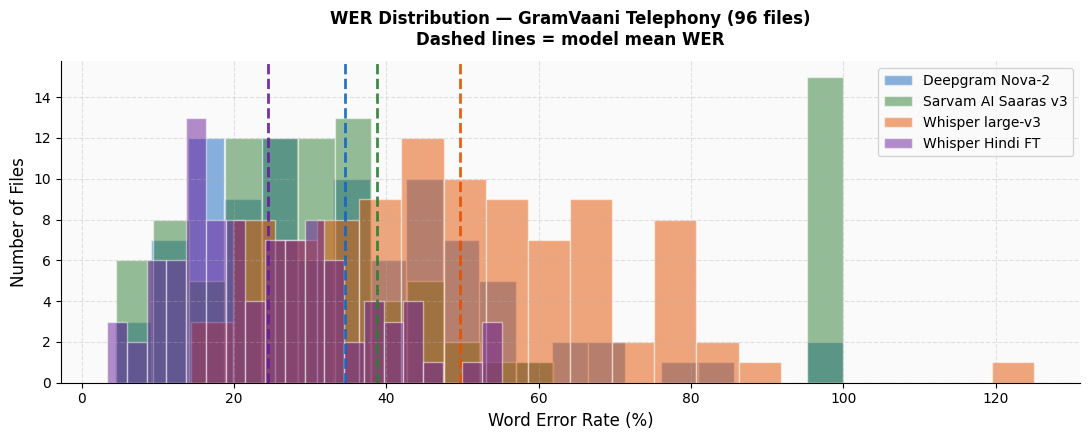

✅ Chart 8 saved


In [ ]:
# ── 6.4 GramVaani WER Distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

for m in MODELS:
    wdata = gv_m[gv_m["model"]==m]["wer"].dropna() * 100
    ax.hist(wdata, bins=20, alpha=0.5, label=LABELS[m].replace("\n"," "),
            color=COLORS[m], edgecolor="white")
    ax.axvline(wdata.mean(), color=COLORS[m],
               linestyle="--", linewidth=2, alpha=0.9)

ax.set_xlabel("Word Error Rate (%)", fontsize=12)
ax.set_ylabel("Number of Files", fontsize=12)
ax.set_title("WER Distribution — GramVaani Telephony (96 files)\n"
             "Dashed lines = model mean WER",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/08_wer_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 8 saved")


In [ ]:
# ── 6.5 Noise Degradation Summary ───────────────────────────────────
print("\nNoise degradation: Quiet → Noisy (entity accuracy drop)")
print("-" * 50)
for m in MODELS:
    q = sf_m[(sf_m["model"]==m)&(sf_m["condition"]=="quiet")]["entity_hit"].mean()*100
    n = sf_m[(sf_m["model"]==m)&(sf_m["condition"]=="noisy")]["entity_hit"].mean()*100
    w = sf_m[(sf_m["model"]==m)&(sf_m["condition"]=="whisper")]["entity_hit"].mean()*100
    r = sf_m[(sf_m["model"]==m)&(sf_m["condition"]=="rushed")]["entity_hit"].mean()*100
    worst = min(q,n,w,r)
    worst_c = ["quiet","noisy","whisper","rushed"][[q,n,w,r].index(worst)]
    print(f"  {m:<16}: quiet={q:.0f}%  noisy={n:.0f}%  "
          f"rushed={r:.0f}%  whisper={w:.0f}%  "
          f"worst={worst_c}({worst:.0f}%)")



Noise degradation: Quiet → Noisy (entity accuracy drop)
--------------------------------------------------
  deepgram        : quiet=80%  noisy=40%  rushed=20%  whisper=0%  worst=whisper(0%)
  sarvam          : quiet=100%  noisy=80%  rushed=60%  whisper=60%  worst=whisper(60%)
  whisper         : quiet=100%  noisy=100%  rushed=80%  whisper=40%  worst=whisper(40%)
  indicwhisper    : quiet=60%  noisy=60%  rushed=20%  whisper=40%  worst=rushed(20%)


## 💾 Section 9 — Export All Results


In [ ]:
# Save final CSVs
df_m.to_csv(f"{RESULTS}/final_metrics1.csv",   index=False, encoding="utf-8-sig")
df_summary.to_csv(f"{RESULTS}/summary_table1.csv", index=False, encoding="utf-8-sig")

charts = sorted(Path(CHART_DIR).glob("*.png"))
print("📊 Saved charts:")
for c in charts:
    size_kb = c.stat().st_size / 1024
    print(f"   {c.name}  ({size_kb:.0f} KB)")

csvs = sorted(Path(RESULTS).glob("*.csv"))
print("\n📄 Saved CSVs:")
for f in csvs:
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name}  ({size_kb:.1f} KB)")

print(f"\n✅ All outputs in {RESULTS}")
print("   Access via Kaggle sidebar → Output → Download")


📊 Saved charts:
   00_dataset_eda.png  (106 KB)
   01_entity_accuracy.png  (76 KB)
   02_wer_cer.png  (88 KB)
   03_latency.png  (72 KB)
   04_entity_by_condition.png  (74 KB)
   05_wer_heatmap.png  (82 KB)
   06_locality_heatmap.png  (159 KB)
   07_radar.png  (207 KB)
   08_wer_distribution.png  (89 KB)

📄 Saved CSVs:
   all_results_metrics.csv  (415.0 KB)
   all_results_raw.csv  (277.2 KB)
   ckpt_deepgram.csv  (68.6 KB)
   ckpt_indicwhisper.csv  (71.3 KB)
   ckpt_sarvam.csv  (67.2 KB)
   ckpt_whisper.csv  (70.4 KB)
   entity_failures.csv  (8.5 KB)
   final_metrics1.csv  (415.0 KB)
   results_deepgram.csv  (68.6 KB)
   results_indicwhisper.csv  (71.3 KB)
   results_sarvam.csv  (67.2 KB)
   results_whisper.csv  (70.4 KB)
   summary_table.csv  (0.4 KB)
   summary_table1.csv  (0.4 KB)

✅ All outputs in /kaggle/working/results
   Access via Kaggle sidebar → Output → Download


In [ ]:
!zip -r results_final.zip /kaggle/working/results


  adding: kaggle/working/results/ (stored 0%)
  adding: kaggle/working/results/ckpt_whisper.csv (deflated 78%)
  adding: kaggle/working/results/all_results_metrics.csv (deflated 75%)
  adding: kaggle/working/results/results_indicwhisper.csv (deflated 81%)
  adding: kaggle/working/results/results_whisper.csv (deflated 78%)
  adding: kaggle/working/results/results_deepgram.csv (deflated 79%)
  adding: kaggle/working/results/entity_failures.csv (deflated 72%)
  adding: kaggle/working/results/ckpt_deepgram.csv (deflated 79%)
  adding: kaggle/working/results/final_metrics1.csv (deflated 75%)
  adding: kaggle/working/results/summary_table1.csv (deflated 26%)
  adding: kaggle/working/results/ckpt_indicwhisper.csv (deflated 81%)
  adding: kaggle/working/results/results_sarvam.csv (deflated 80%)
  adding: kaggle/working/results/ckpt_sarvam.csv (deflated 80%)
  adding: kaggle/working/results/summary_table.csv (deflated 26%)
  adding: kaggle/working/results/all_results_raw.csv (deflated 80%)
  ad